# Spaceflight–Disease Separation — Visualisations
**NetMedPy · PCNet 2.2 · Query: Spaceflight Module**

Loads results from `2_separation_pipeline.ipynb` and produces six
publication-ready plots saved to `data/output/plots/` at 300 dpi.

**Prerequisite:** Run `2_separation_pipeline.ipynb` first. Required files:
- `data/output/csv/separation_summary.csv`
- `data/output/benchmark.json` (for `EMPIRICAL_Z_THRESH`)

**Plots produced:**

| Plot | File | Description |
|---|---|---|
| 1 | `plot1_zscore_landscape.png` | Ranked z-score landscape — all disease modules |
| 2 | `plot2_size_stratification.png` | Z-score by module size strata |
| 3 | `plot3_separation_barchart.png` | Top-20 FDR-significant diseases, horizontal bar |
| 4 | `plot4_geometric_vs_statistical.png` | Geometric vs statistical separation (s_AB vs z) |
| 5 | `plot5_pvalue_distributions.png` | Raw and BH-adjusted p-value histograms |
| 6 | `plot6_genesetsize_bias.png` | Gene set size bias check (log₁₀ scale) |


## Step 1 — Imports and Load Results

Loads `separation_summary.csv` and `benchmark.json`. The `EMPIRICAL_Z_THRESH`
written by the pipeline notebook is read from `benchmark.json` so it does not
need to be hardcoded here.


In [1]:
# Shared pipeline utilities (load, save, etc.) are in utils.py.
# This notebook uses only standard library + pandas/matplotlib.

import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats

# ── Path constants ────────────────────────────────────────────────────────────
SUMMARY_CSV = "data/output/csv/separation_summary.csv"
BENCH_PATH  = "data/output/benchmark.json"
PLOT_DIR    = "data/output/plots"
QUERY_KEY   = "spaceflight"

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Load results ──────────────────────────────────────────────────────────────
if not os.path.exists(SUMMARY_CSV):
    raise FileNotFoundError(
        f"{SUMMARY_CSV} not found. Run 2_separation_pipeline.ipynb first."
    )

results = pd.read_csv(SUMMARY_CSV)
print(f"Loaded {len(results)} disease results from {SUMMARY_CSV}")
print(results[["disease", "z_score", "relationship"]].head())

# ── Load empirical z-threshold ────────────────────────────────────────────────
EMPIRICAL_Z_THRESH = 2.20  # fallback default

if os.path.exists(BENCH_PATH):
    with open(BENCH_PATH) as f:
        bench_cfg = json.load(f)
    loaded_thresh = bench_cfg.get("empirical_z_thresh")
    if loaded_thresh is not None:
        EMPIRICAL_Z_THRESH = float(loaded_thresh)
        print(f"Empirical z-threshold loaded from benchmark.json: {EMPIRICAL_Z_THRESH:.2f}")
    else:
        print(f"empirical_z_thresh not in benchmark.json — using fallback {EMPIRICAL_Z_THRESH}")
else:
    print(f"benchmark.json not found — using fallback EMPIRICAL_Z_THRESH={EMPIRICAL_Z_THRESH}")

# ── Restore size_bin column (lost on CSV round-trip) ─────────────────────────
results["size_bin"] = pd.cut(
    results["n_genes"],
    bins=[0, 50, 150, 99999],
    labels=["Small (≤50 genes)", "Medium (51–150 genes)", "Large (>150 genes)"],
)


Loaded 265 disease results from data/output/csv/separation_summary.csv
                                             disease   z_score relationship
0                                  Hodgkins lymphoma -1.819776      Neutral
1  carcinoma of liver and intrahepatic biliary tract -1.198915      Neutral
2                           hepatocellular carcinoma -1.034436      Neutral
3                                           dementia -0.962880      Neutral
4                                     ovarian cancer -0.958972      Neutral
Empirical z-threshold loaded from benchmark.json: 2.20


## Step 2 — Shared Style and Colour Scheme

All plot styling is centralised here. Adjust font sizes, colours, or rcParams
once and all six plots update consistently.

Colour palette (`#2166ac / #f4a582 / #d6604d`) is colourblind-safe.


In [2]:
plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "figure.autolayout": True,
    "font.size":          12,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

COLORS = {
    "Overlapping": "#2166ac",
    "Neutral":     "#f4a582",
    "Separated":   "#d6604d",
}

point_colors = results["relationship"].map(COLORS)

legend_patches = [
    mpatches.Patch(facecolor=COLORS["Overlapping"], label="Overlapping (FDR < 0.05, z < 0)"),
    mpatches.Patch(facecolor=COLORS["Neutral"],     label="Neutral (FDR ≥ 0.05)"),
    mpatches.Patch(facecolor=COLORS["Separated"],   label="Separated (FDR < 0.05, z > 0)"),
]

print(f"Style configured. EMPIRICAL_Z_THRESH = {EMPIRICAL_Z_THRESH}")
print(f"All plots will be saved to: {PLOT_DIR}/")


Style configured. EMPIRICAL_Z_THRESH = 2.2000000000000015
All plots will be saved to: data/output/plots/


## Plot 1 — Ranked Z-Score Landscape

All disease modules ranked by separation z-score. Colour encodes relationship category. Dotted lines mark the empirical z-threshold at ±`EMPIRICAL_Z_THRESH`.

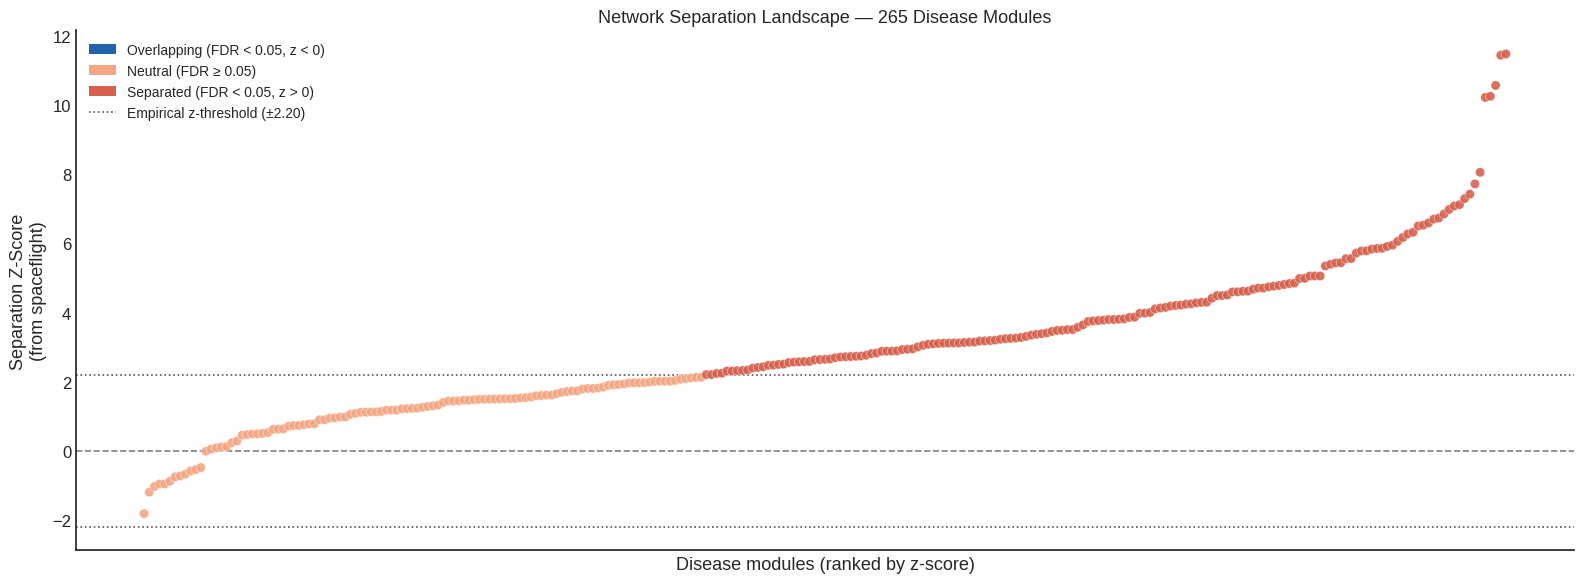

Saved: data/output/plots/plot1_zscore_landscape.png


In [3]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.axhline(0, ls="--", lw=1.2, color="grey", zorder=1)
ax.axhline( EMPIRICAL_Z_THRESH, ls=":", lw=1.2, color="#555555", zorder=1)
ax.axhline(-EMPIRICAL_Z_THRESH, ls=":", lw=1.2, color="#555555", zorder=1)

ax.scatter(
    range(len(results)), results["z_score"],
    c=point_colors, s=45, alpha=0.9, edgecolors="white", lw=0.3, zorder=2,
)

ax.set_ylabel(f"Separation Z-Score\n(from {QUERY_KEY})", fontsize=13)
ax.set_xlabel("Disease modules (ranked by z-score)", fontsize=13)
ax.set_title(f"Network Separation Landscape — {len(results)} Disease Modules", fontsize=13)
ax.set_xticks([])

ref_line = Line2D([0], [0], ls=":", color="#555555", lw=1.2,
                  label=f"Empirical z-threshold (±{EMPIRICAL_Z_THRESH:.2f})")
ax.legend(handles=legend_patches + [ref_line], loc="upper left", frameon=False, fontsize=10)

out_path = os.path.join(PLOT_DIR, "plot1_zscore_landscape.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Plot 2 — Z-Score Distribution by Module Size Strata

Three-panel scatter showing z-score vs. disease rank within each size bin (small / medium / large). Dashed grey = z = 0; solid dark = per-bin median z-score. Shared y-axis.

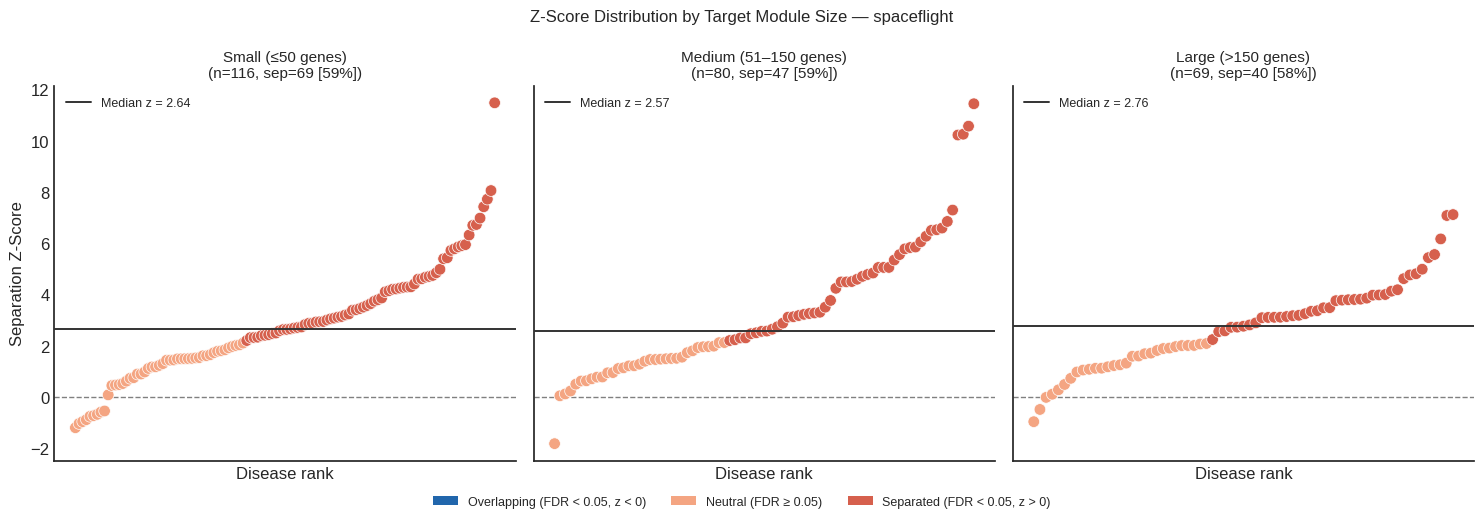

Saved: data/output/plots/plot2_size_stratification.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bin_labels = results["size_bin"].cat.categories

for ax, label in zip(axes, bin_labels):
    subset     = results[results["size_bin"] == label].reset_index(drop=True)
    sub_colors = subset["relationship"].map(COLORS)

    ax.scatter(range(len(subset)), subset["z_score"].values,
               c=sub_colors, s=70, edgecolors="white", lw=0.5, zorder=2)
    ax.axhline(0, ls="--", color="grey", lw=1.0, zorder=1)

    med_z = subset["z_score"].median()
    ax.axhline(med_z, ls="-", color="#333333", lw=1.4, zorder=3,
               label=f"Median z = {med_z:.2f}")

    n_sep = (subset["relationship"] == "Separated").sum()
    pct   = n_sep / len(subset) * 100
    ax.set_title(f"{label}\n(n={len(subset)}, sep={n_sep} [{pct:.0f}%])", fontsize=11)
    ax.set_xlabel("Disease rank", fontsize=12)
    ax.tick_params(axis="x", labelbottom=False)
    ax.legend(frameon=False, fontsize=9, loc="upper left")

axes[0].set_ylabel("Separation Z-Score", fontsize=12)
fig.suptitle(f"Z-Score Distribution by Target Module Size — {QUERY_KEY}", fontsize=12)
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "plot2_size_stratification.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Plot 3 — Top-20 Most Separated Diseases

Top-20 FDR-significant diseases ranked by z-score. Star annotations encode FDR significance level. Dashed vertical line = empirical z-threshold.

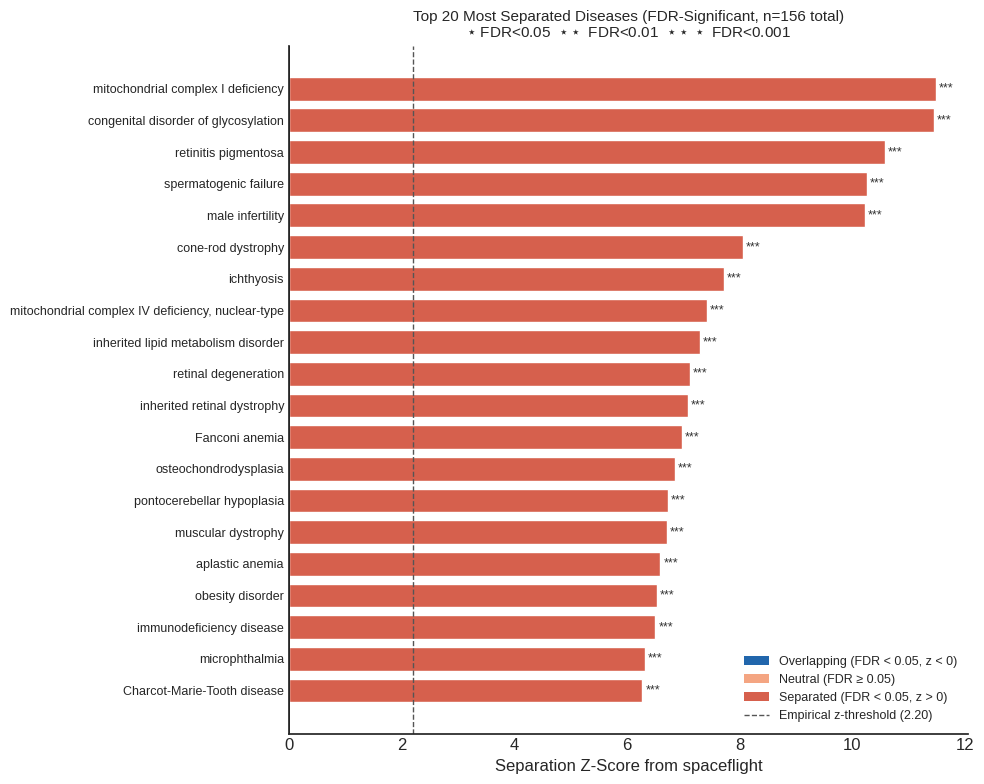

Saved: data/output/plots/plot3_separation_barchart.png


In [5]:
N_TOP = 20

sig_results = (
    results[results["p_adj_fdr"] < 0.05]
    .copy()
    .sort_values("z_score", ascending=True)
    .reset_index(drop=True)
)
n_sig  = len(sig_results)
top_df  = sig_results.tail(N_TOP)   # tail = highest z after ascending sort
n_shown = len(top_df)               # may be < N_TOP if fewer sig diseases exist

fig, ax = plt.subplots(figsize=(10, max(4, n_shown * 0.4)))

ax.barh(range(n_shown), top_df["z_score"].values,
        color=top_df["relationship"].map(COLORS).values,
        edgecolor="white", height=0.75)
ax.axvline(x=0, color="black", lw=1.2)
ax.axvline(x=EMPIRICAL_Z_THRESH, color="#555555", lw=1.0, ls="--")

for i, (_, row) in enumerate(top_df.iterrows()):
    star = row["sig_fdr"] if row["sig_fdr"] != "ns" else ""
    if star:
        ax.text(row["z_score"] + 0.05, i, star, va="center", fontsize=9, color="#333333")

ax.set_yticks(range(n_shown))
ax.set_yticklabels(top_df["disease"].values, fontsize=9)
ax.set_xlabel(f"Separation Z-Score from {QUERY_KEY}", fontsize=12)
ax.set_title(
    f"Top {N_TOP} Most Separated Diseases (FDR-Significant, n={n_sig} total)\n"
    r"$\star$ FDR<0.05  $\star\star$ FDR<0.01  $\star\star\star$ FDR<0.001",
    fontsize=11,
)
ax.legend(handles=legend_patches + [
    Line2D([0], [0], ls="--", color="#555555", lw=1.0,
           label=f"Empirical z-threshold ({EMPIRICAL_Z_THRESH:.2f})")
], loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "plot3_separation_barchart.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Plot 4 — Geometric vs. Statistical Separation

Scatter of raw separation score (s_AB) vs. z-score for all disease modules, with linear regression line.

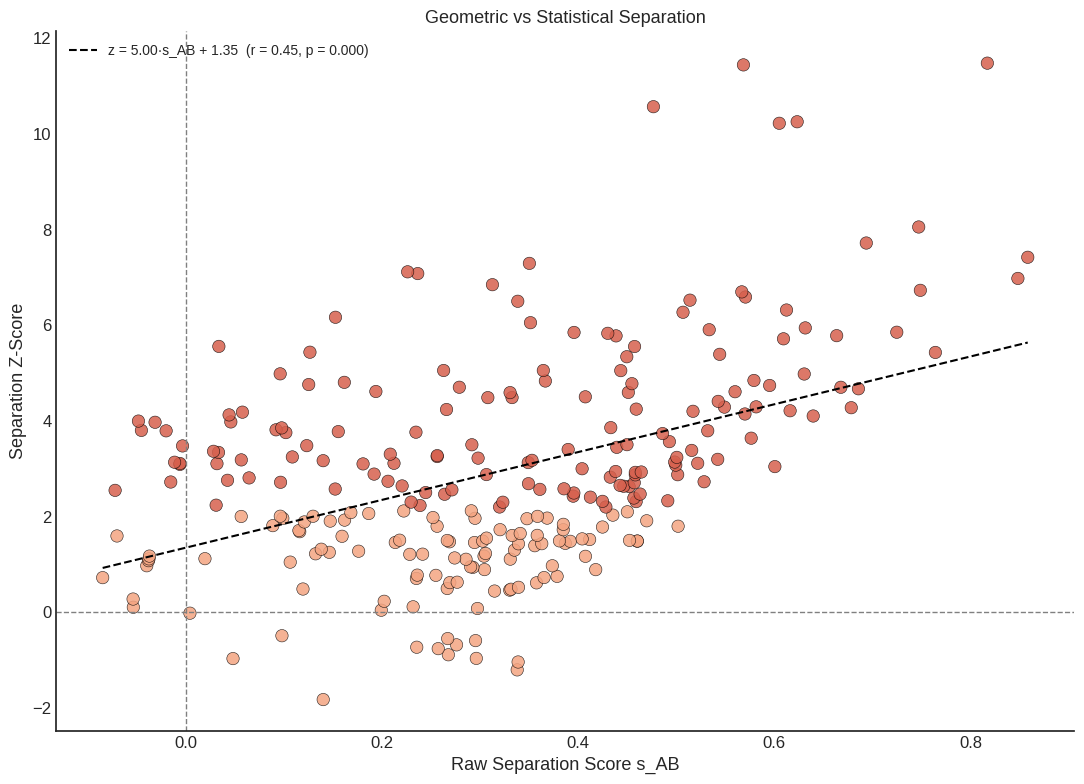

Saved: data/output/plots/plot4_geometric_vs_statistical.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(results["separation"], results["z_score"],
           c=point_colors, s=80, edgecolors="black", lw=0.4, alpha=0.85, zorder=2)

m, b, r, p_r, _ = stats.linregress(results["separation"], results["z_score"])
x_line = np.linspace(results["separation"].min(), results["separation"].max(), 200)
ax.plot(x_line, m * x_line + b, color="black", lw=1.5, ls="--",
        label=f"z = {m:.2f}·s_AB + {b:.2f}  (r = {r:.2f}, p = {p_r:.3f})", zorder=3)

ax.axhline(0, ls="--", color="grey", lw=1.0)
ax.axvline(0, ls="--", color="grey", lw=1.0)
ax.set_xlabel("Raw Separation Score s_AB", fontsize=13)
ax.set_ylabel("Separation Z-Score", fontsize=13)
ax.set_title("Geometric vs Statistical Separation", fontsize=13)
ax.legend(loc="upper left", frameon=False, fontsize=10)

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "plot4_geometric_vs_statistical.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Plot 5 — P-value Distributions

Histograms of raw empirical p-values and BH-FDR-adjusted p-values. A spike near zero with an otherwise flat raw distribution indicates genuine signal.

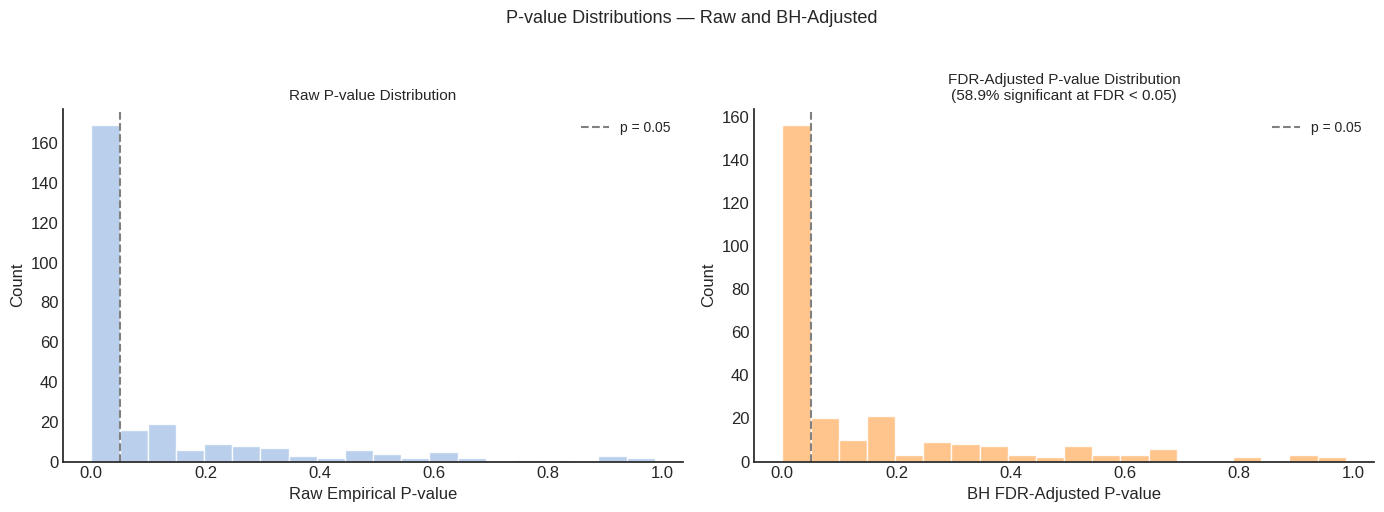

Saved: data/output/plots/plot5_pvalue_distributions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def _hist(ax, data, color, vline_val, xlabel, title):
    ax.hist(data, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(x=vline_val, color="grey", ls="--", lw=1.5, label=f"p = {vline_val}")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(frameon=False, fontsize=10)

_hist(axes[0], results["p_value"], "#aec7e8", 0.05,
      "Raw Empirical P-value", "Raw P-value Distribution")

frac_sig = (results["p_adj_fdr"] < 0.05).mean() * 100
_hist(axes[1], results["p_adj_fdr"], "#ffbb78", 0.05,
      "BH FDR-Adjusted P-value",
      f"FDR-Adjusted P-value Distribution\n({frac_sig:.1f}% significant at FDR < 0.05)")

plt.suptitle("P-value Distributions — Raw and BH-Adjusted", fontsize=13, y=1.02)
plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "plot5_pvalue_distributions.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Plot 6 — Gene Set Size Bias Check

Regression of z-score on $\log_{10}$(gene set size). A near-zero slope
confirms the null model is not inflated by large gene sets.


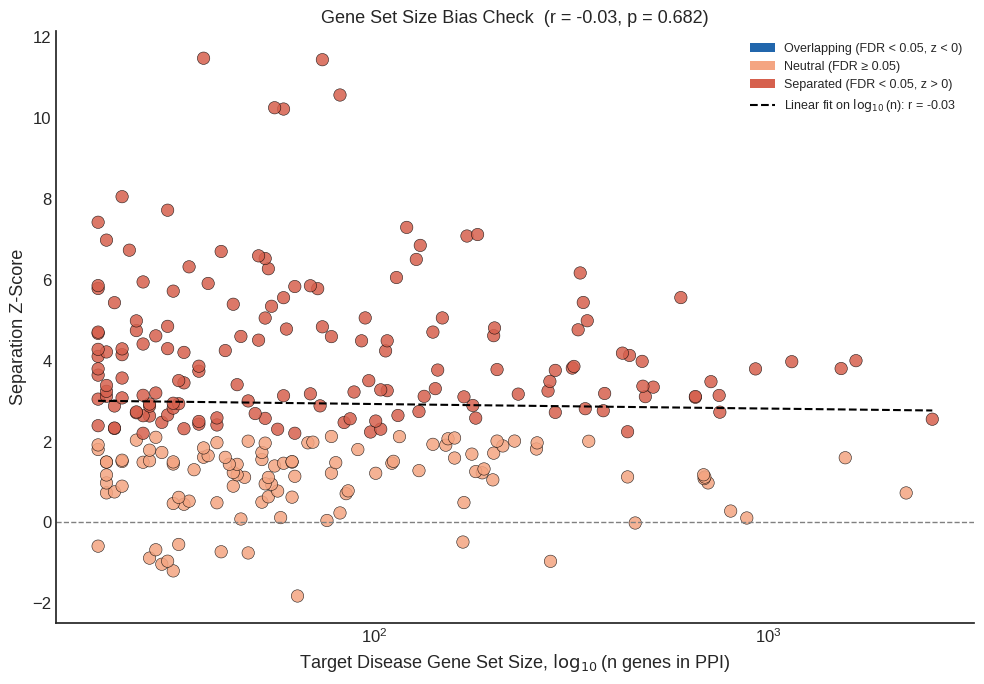

Saved: data/output/plots/plot6_genesetsize_bias.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(results["n_genes"], results["z_score"],
           c=results["relationship"].map(COLORS),
           s=80, edgecolors="black", lw=0.4, alpha=0.85, zorder=2)

log_n            = np.log10(results["n_genes"])
m2, b2, r2, p2, _ = stats.linregress(log_n, results["z_score"])
x2_log           = np.linspace(log_n.min(), log_n.max(), 200)
ax.plot(10 ** x2_log, m2 * x2_log + b2, color="black", lw=1.5, ls="--", zorder=3)
# Regression line label is carried by the explicit Line2D added to the legend handles below.

ax.axhline(0, ls="--", color="grey", lw=1.0)
ax.set_xscale("log")
ax.set_xlabel(r"Target Disease Gene Set Size, $\log_{10}$(n genes in PPI)", fontsize=13)
ax.set_ylabel("Separation Z-Score", fontsize=13)
ax.set_title(f"Gene Set Size Bias Check  (r = {r2:.2f}, p = {p2:.3f})", fontsize=13)
ax.legend(
    handles=legend_patches + [
        Line2D([0], [0], ls="--", color="black", lw=1.5,
               label=r"Linear fit on $\log_{10}$(n): " + f"r = {r2:.2f}")
    ],
    loc="upper right", frameon=False, fontsize=9,
)

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "plot6_genesetsize_bias.png")
plt.savefig(out_path)
plt.show()
print(f"Saved: {out_path}")


## Summary — All Plots Saved

In [9]:
print(f"Plots saved to {PLOT_DIR}/")
print()
for fname in sorted(os.listdir(PLOT_DIR)):
    fpath    = os.path.join(PLOT_DIR, fname)
    size_kb  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<50}  {size_kb:>7.1f} KB")


Plots saved to data/output/plots/

  plot1_zscore_landscape.png                            330.9 KB
  plot2_size_stratification.png                         332.1 KB
  plot3_separation_barchart.png                         284.8 KB
  plot4_geometric_vs_statistical.png                    518.3 KB
  plot5_pvalue_distributions.png                        154.8 KB
  plot6_genesetsize_bias.png                            503.6 KB
